In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

from apyori import apriori


In [ ]:
df = pd.read_csv(
    r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv"
)

df.head()


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [3]:
df.shape


(100000, 20)

In [ ]:
df_sample = df.sample(n=8000, random_state=42)

features = [
    "Age",
    "Monthly_Salary",
    "Years_At_Company",
    "Projects_Handled",
    "Overtime_Hours",
    "Employee_Satisfaction_Score"
]

X = df_sample[features]


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


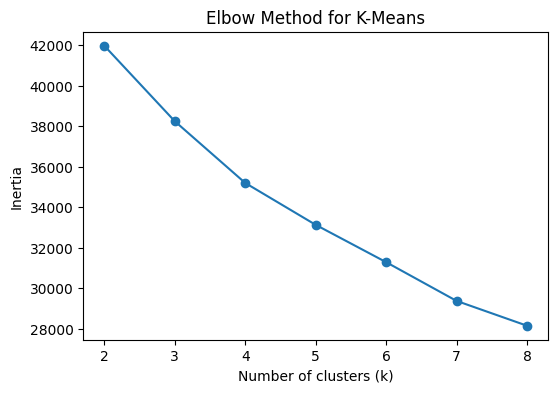

In [6]:
inertia = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,9), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_sample["KMeans_Cluster"] = clusters


In [8]:
df_sample["KMeans_Cluster"].value_counts()


KMeans_Cluster
2    2934
1    2534
0    2532
Name: count, dtype: int64

In [9]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

centroids


,Age,Monthly_Salary,Years_At_Company,Projects_Handled,Overtime_Hours,Employee_Satisfaction_Score
0,41.821950,6234.563758,6.368733,22.637584,22.185156,2.897233
1,39.492696,6447.473352,6.144493,26.814844,6.345045,3.059171
2,41.544649,6522.716428,1.414792,23.417178,14.904226,2.977849


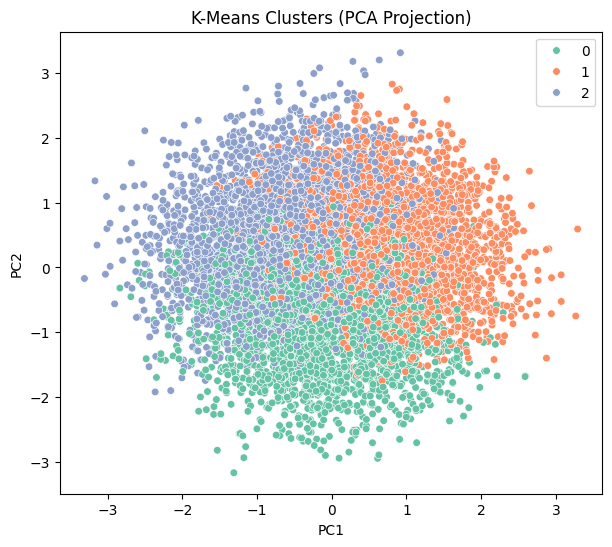

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="Set2",
    s=30
)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
Z_single = linkage(X_scaled, method="single")


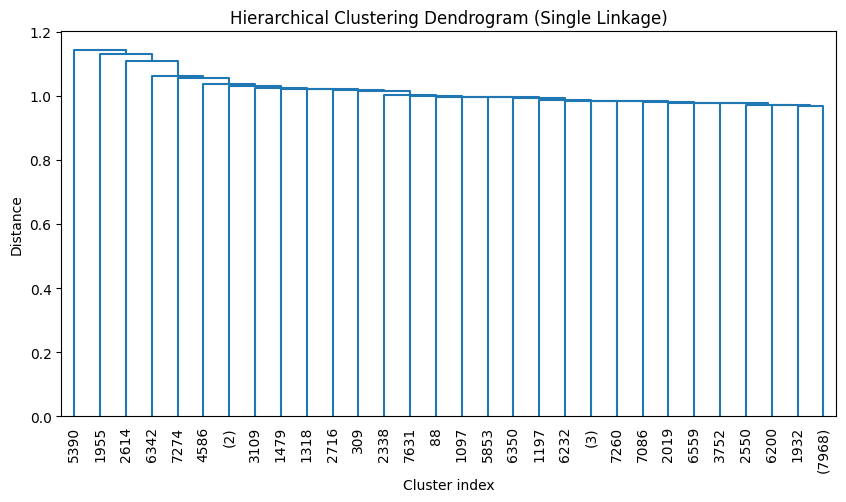

In [12]:
plt.figure(figsize=(10, 5))
dendrogram(
    Z_single,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
plt.xlabel("Cluster index")
plt.ylabel("Distance")
plt.show()


In [13]:
# COMPLETE LINKAGE
Z_complete = linkage(X_scaled, method="complete")


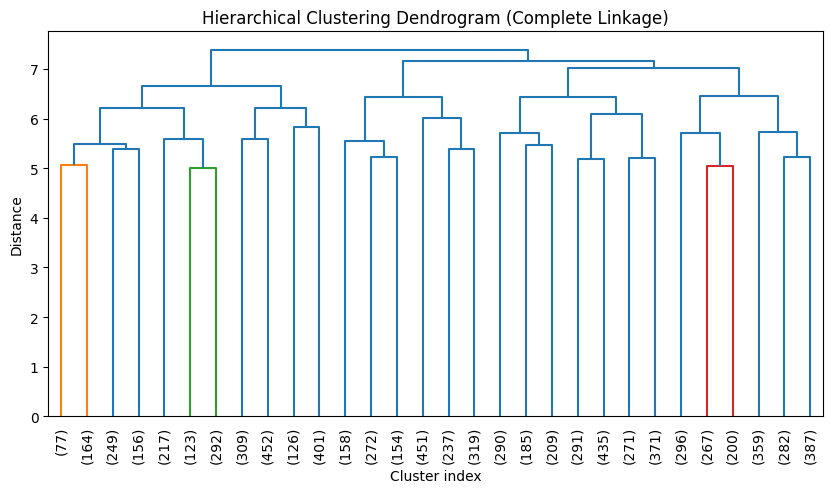

In [14]:
plt.figure(figsize=(10, 5))
dendrogram(
    Z_complete,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Cluster index")
plt.ylabel("Distance")
plt.show()


In [15]:
from sklearn.cluster import DBSCAN


In [16]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=10
)


In [17]:
dbscan_labels = dbscan.fit_predict(X_scaled)


In [18]:
df_sample["DBSCAN_Cluster"] = dbscan_labels


In [19]:
df_sample["DBSCAN_Cluster"].value_counts()


DBSCAN_Cluster
-1    7924
 4      18
 3      17
 2      11
 0      10
 5      10
 1      10
Name: count, dtype: int64

In [20]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)


Number of clusters: 6
Number of noise points: 7924


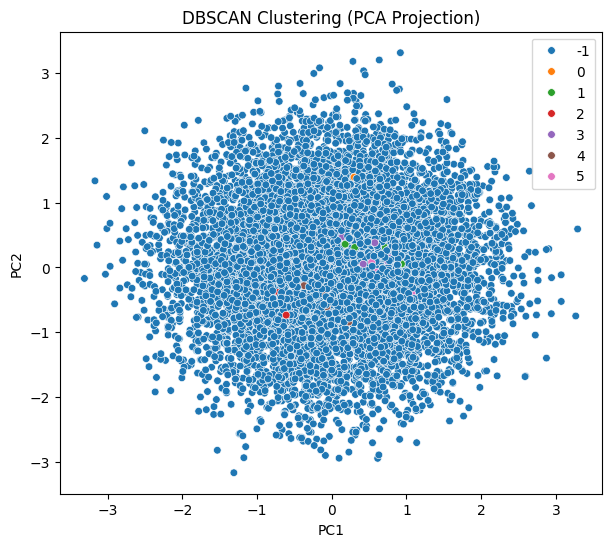

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=dbscan_labels,
    palette="tab10",
    s=30,
    legend="full"
)

plt.title("DBSCAN Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [22]:
# AGE GROUP
df_sample["Age_Group"] = pd.cut(
    df_sample["Age"],
    bins=[18, 30, 45, 65],
    labels=["Young", "MidCareer", "Senior"]
)

# SALARY LEVEL
df_sample["Salary_Level"] = pd.cut(
    df_sample["Monthly_Salary"],
    bins=[0, 5000, 8000, np.inf],
    labels=["Low", "Medium", "High"]
)

# PERFORMANCE LEVEL
df_sample["Performance_Level"] = df_sample["Performance_Score"].map({
    1: "Very_Low",
    2: "Low",
    3: "Medium",
    4: "High",
    5: "Very_High"
})

# SATISFACTION LEVEL
df_sample["Satisfaction_Level"] = pd.cut(
    df_sample["Employee_Satisfaction_Score"],
    bins=[0, 2.5, 3.5, 5],
    labels=["Low", "Medium", "High"]
)


In [23]:
apriori_df = df_sample[
    [
        "Age_Group",
        "Salary_Level",
        "Education_Level",
        "Department",
        "Performance_Level",
        "Satisfaction_Level",
        "Resigned"
    ]
].astype(str)


In [24]:
transactions = apriori_df.values.tolist()


In [ ]:
from apyori import apriori

rules = apriori(
    transactions,
    min_support=0.02,   
    min_confidence=0.4,  
    min_lift=1.2,
    min_length=2
)

rules_list = list(rules)
len(rules_list)


8

In [26]:
association_results = []

for rule in rules_list:
    support = rule.support
    for ordered_stat in rule.ordered_statistics:
        if len(ordered_stat.items_base) > 0:
            association_results.append({
                "Rule": f"{set(ordered_stat.items_base)} → {set(ordered_stat.items_add)}",
                "Support": support,
                "Confidence": ordered_stat.confidence,
                "Lift": ordered_stat.lift
            })

rules_df = pd.DataFrame(association_results)
rules_df.sort_values(by="Lift", ascending=False).head(10)


,Rule,Support,Confidence,Lift
7,"{'Very_High', 'Young'} → {'False', 'High'}",0.026250,0.603448,1.256857
9,"{'Very_High', 'Bachelor', 'Senior'} → {'False'...",0.024125,0.603125,1.256183
2,"{'Very_High', 'Bachelor'} → {'False', 'High'}",0.058750,0.591940,1.232886
8,"{'Very_High', 'False', 'Young'} → {'High'}",0.026250,0.656250,1.223206
1,"{'Very_High', 'Young'} → {'High'}",0.028500,0.655172,1.221197
0,"{'Very_High'} → {'False', 'High'}",0.114125,0.584133,1.216627
10,"{'Very_High', 'Bachelor', 'False', 'Senior'} →...",0.024125,0.652027,1.215335
3,"{'Very_High', 'Bachelor', 'False'} → {'High'}",0.058750,0.648276,1.208343
4,"{'Very_High', 'Bachelor', 'Senior'} → {'High'}",0.025875,0.646875,1.205732
6,"{'Very_High', 'Senior'} → {'False', 'High'}",0.046000,0.578616,1.205137


In [27]:
X = df_sample.drop(columns=["Resigned"])
y = df_sample["Resigned"]


In [28]:
X_encoded = pd.get_dummies(X, drop_first=True)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8983333333333333
              precision    recall  f1-score   support

       False       0.90      1.00      0.95      2156
        True       0.00      0.00      0.00       244

    accuracy                           0.90      2400
   macro avg       0.45      0.50      0.47      2400
weighted avg       0.81      0.90      0.85      2400



c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [31]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.8,
    random_state=42
)


In [32]:
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))


AdaBoost Accuracy: 0.8983333333333333
              precision    recall  f1-score   support

       False       0.90      1.00      0.95      2156
        True       0.00      0.00      0.00       244

    accuracy                           0.90      2400
   macro avg       0.45      0.50      0.47      2400
weighted avg       0.81      0.90      0.85      2400



c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


In [40]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8979166666666667
              precision    recall  f1-score   support

       False       0.90      1.00      0.95      2156
        True       0.00      0.00      0.00       244

    accuracy                           0.90      2400
   macro avg       0.45      0.50      0.47      2400
weighted avg       0.81      0.90      0.85      2400



In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["Decision Tree", "AdaBoost", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt, pos_label=True),
        precision_score(y_test, y_pred_ada, pos_label=True),
        precision_score(y_test, y_pred_rf, pos_label=True)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt, pos_label=True),
        recall_score(y_test, y_pred_ada, pos_label=True),
        recall_score(y_test, y_pred_rf, pos_label=True)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dt, pos_label=True),
        f1_score(y_test, y_pred_ada, pos_label=True),
        f1_score(y_test, y_pred_rf, pos_label=True)
    ]
})

results



c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eren_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.898333,0.0,0.0,0.0
1,AdaBoost,0.898333,0.0,0.0,0.0
2,Random Forest,0.897917,0.0,0.0,0.0


In [43]:
df_perf = df_sample.copy()

df_perf = df_perf[df_perf["Performance_Score"] != 3]

df_perf["High_Performance"] = df_perf["Performance_Score"].apply(
    lambda x: 1 if x >= 4 else 0
)


In [53]:
df_perf["High_Performance"].value_counts(normalize=True)


High_Performance
0    0.509452
1    0.490548
Name: proportion, dtype: float64

In [ ]:
X = df_perf.drop(columns=[
    "Performance_Score",
    "High_Performance",
    "Employee_Satisfaction_Score"
])

y = df_perf["High_Performance"]


In [55]:
X_encoded = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))



Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       979
           1       1.00      1.00      1.00       942

    accuracy                           1.00      1921
   macro avg       1.00      1.00      1.00      1921
weighted avg       1.00      1.00      1.00      1921



In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       979
           1       1.00      1.00      1.00       942

    accuracy                           1.00      1921
   macro avg       1.00      1.00      1.00      1921
weighted avg       1.00      1.00      1.00      1921



In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

df = pd.read_csv(
    r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv"
)

TARGET = "Resigned"
DROP_COLS = ["Employee_ID", "Hire_Date"]

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET].astype(int)

# Feature groups
cat_cols = ["Department", "Gender", "Job_Title", "Education_Level"]
cat_cols = [c for c in cat_cols if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Resigned rate:", y.mean())


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

models = {
    "Decision Tree (stump)": DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=300,
        learning_rate=0.5,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
}

def evaluate(pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_te)[:, 1]
    else:
        y_score = None

    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision(1)": precision_score(y_te, y_pred, zero_division=0),
        "Recall(1)": recall_score(y_te, y_pred, zero_division=0),
        "F1(1)": f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_score) if y_score is not None else np.nan,
        "Confusion Matrix": confusion_matrix(y_te, y_pred)
    }

results = []

for name, clf in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", clf)
    ])

    if name != "Random Forest":
        pipe.fit(X_train, y_train, clf__sample_weight=sample_weight)
    else:
        pipe.fit(X_train, y_train)

    metrics = evaluate(pipe, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model")
display(results_df[["Accuracy", "Precision(1)", "Recall(1)", "F1(1)", "ROC-AUC"]])

print("\nConfusion Matrices:")
for m, cm in zip(results_df.index, results_df["Confusion Matrix"]):
    print(f"\n{m}")
    print(cm)


Resigned rate: 0.1001


,Accuracy,Precision(1),Recall(1),F1(1),ROC-AUC
Model,,,,,
Decision Tree (stump),0.25645,0.100118,0.804695,0.17808,0.500081
AdaBoost,0.49135,0.097607,0.495005,0.16306,0.492205
Random Forest,0.89990,0.000000,0.000000,0.00000,0.487625



Confusion Matrices:

Decision Tree (stump)
[[ 3518 14480]
 [  391  1611]]

AdaBoost
[[8836 9162]
 [1011  991]]

Random Forest
[[17998     0]
 [ 2002     0]]
